# CAB420 Assignment 1A Question 2: Classification
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 2. It simply implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [31]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import PredefinedSplit

In [33]:
# load data
train = pd.read_csv('./data/Q2/training.csv')
val = pd.read_csv('./data/Q2/validation.csv')
test = pd.read_csv('./data/Q2/testing.csv')

# pull out X and y data, convert to np
X_train = train.iloc[:,1:].to_numpy()
y_train = train.iloc[:,0].to_numpy()
X_val = val.iloc[:,1:].to_numpy()
y_val = val.iloc[:,0].to_numpy()
X_test = test.iloc[:,1:].to_numpy()
y_test = test.iloc[:,0].to_numpy()

## Exploratory Data Analysis

The Exploratory Data Analysis informs the methodology, pre-processing and the final regression implementation

### Available Data

Exploring the available data will inform the later EDA

In [34]:
# See train set head
display(train.head())

,class,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,pred_minus_obs_H_b9,pred_minus_obs_S_b1,pred_minus_obs_S_b2,pred_minus_obs_S_b3,pred_minus_obs_S_b4,pred_minus_obs_S_b5,pred_minus_obs_S_b6,pred_minus_obs_S_b7,pred_minus_obs_S_b8,pred_minus_obs_S_b9
0,d,39,36,57,91,59,101,93,27,60,...,-2.36,-18.41,-1.88,-6.43,-21.03,-1.60,-6.18,-22.50,-5.20,-7.86
1,h,84,30,57,112,51,98,92,26,62,...,-2.26,-16.27,-1.95,-6.25,-18.79,-1.99,-6.18,-23.41,-8.87,-10.83
2,s,53,25,49,99,51,93,84,26,58,...,-1.46,-15.92,-1.79,-4.64,-17.73,-0.48,-4.69,-19.97,-4.10,-7.07
3,s,59,26,49,103,47,92,82,25,56,...,2.68,-13.77,-2.53,-6.34,-22.03,-2.34,-6.60,-27.10,-7.99,-10.81
4,d,57,49,66,103,64,106,114,28,59,...,-2.94,-21.74,-1.64,-4.62,-23.74,-0.85,-5.50,-22.83,-2.74,-5.84


In [35]:
# See dataset shapes
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total Shape": [train.shape, val.shape, test.shape],
            "X Shape": [X_train.shape, X_val.shape, X_test.shape],
            "y Shape": [y_train.shape, y_val.shape, y_test.shape]
        }
    )
)

,Dataset,Total Shape,X Shape,y Shape
0,Train,"(198, 28)","(198, 27)","(198,)"
1,Validation,"(164, 28)","(164, 27)","(164,)"
2,Test,"(161, 28)","(161, 27)","(161,)"


In [36]:
# Check columnn data types
display(
    pd.DataFrame(
    {
        "Dataset" : ["Train", "Validation", "Test"],
        "X types": [X_train.dtype, X_val.dtype, X_test.dtype],
        "y types": [y_train.dtype, y_val.dtype, y_test.dtype]
    }
    ).join(
        pd.DataFrame(
            [train.dtypes.value_counts(), val.dtypes.value_counts(), test.dtypes.value_counts()]
        ).reset_index(drop=True)
    )
)

,Dataset,X types,y types,float64,int64,str
0,Train,float64,object,18,9,1
1,Validation,float64,object,18,9,1
2,Test,float64,object,18,9,1


#### Interpreting Available Data

From the above it can be seen that all the train, validation and test datasets contain 27 predictors, consisting of 9 ints and 18 floats and one string output, the string output appears to be a categorical output. 

This introduces the need to check for invalid numbers and check whether the target column is clean.

### Data Validity

In [37]:
# Check for invalid predictors
display(
    pd.DataFrame(
        {
            "Dataset" : ["Train", "Validation", "Test"],
            "Total null": [train.isnull().sum().sum(), val.isnull().sum().sum(), test.isnull().sum().sum()],
            "Total inf": [np.isinf(X_train).sum().sum(), np.isinf(X_val).sum().sum(), np.isinf(X_test).sum().sum()]
        }
    )
)

,Dataset,Total null,Total inf
0,Train,0,0
1,Validation,0,0
2,Test,0,0


In [38]:
# Check target column

freq = pd.DataFrame(
    np.unique(y_train, return_counts=True),
).T
freq.columns = ['Target', 'Frequency']

display(freq)

,Target,Frequency
0,d,54
1,h,48
2,o,37
3,s,59


#### Interpreting Data Validity

From the above outputs it can be seen that the available data is valid, no null or infinite values in the features and no typo's in the targets. Another observation is that the frequency of the targets are mostly balanced and therefore should be correctly represented in the model. 

### Data Distributions

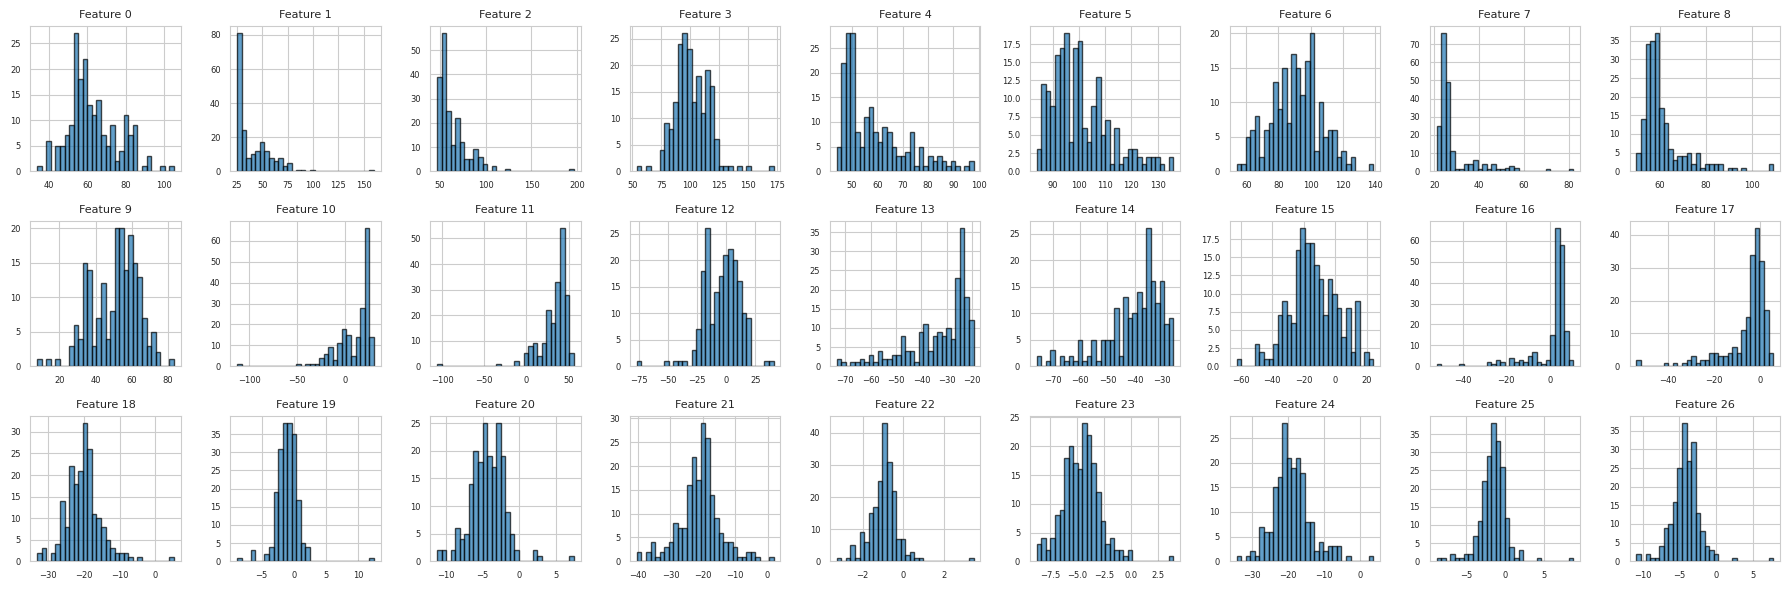

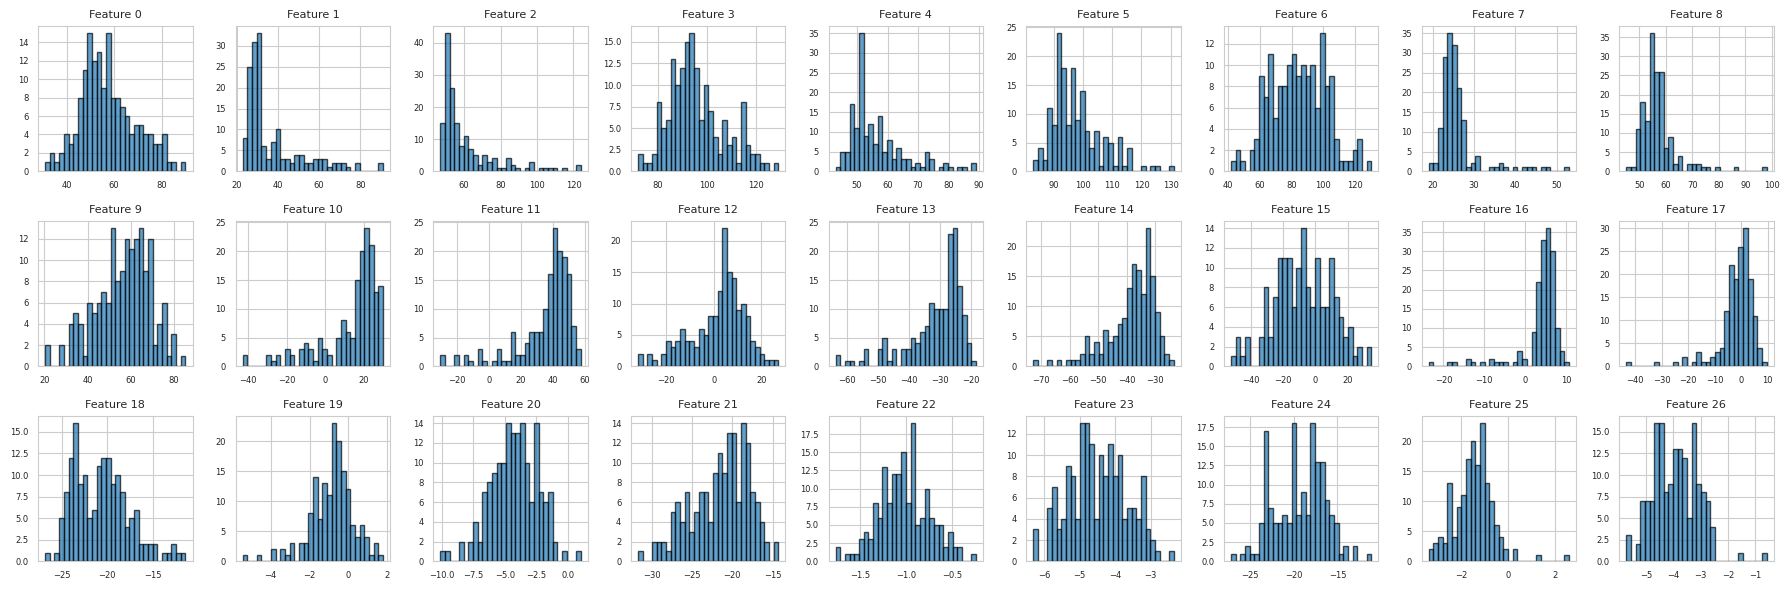

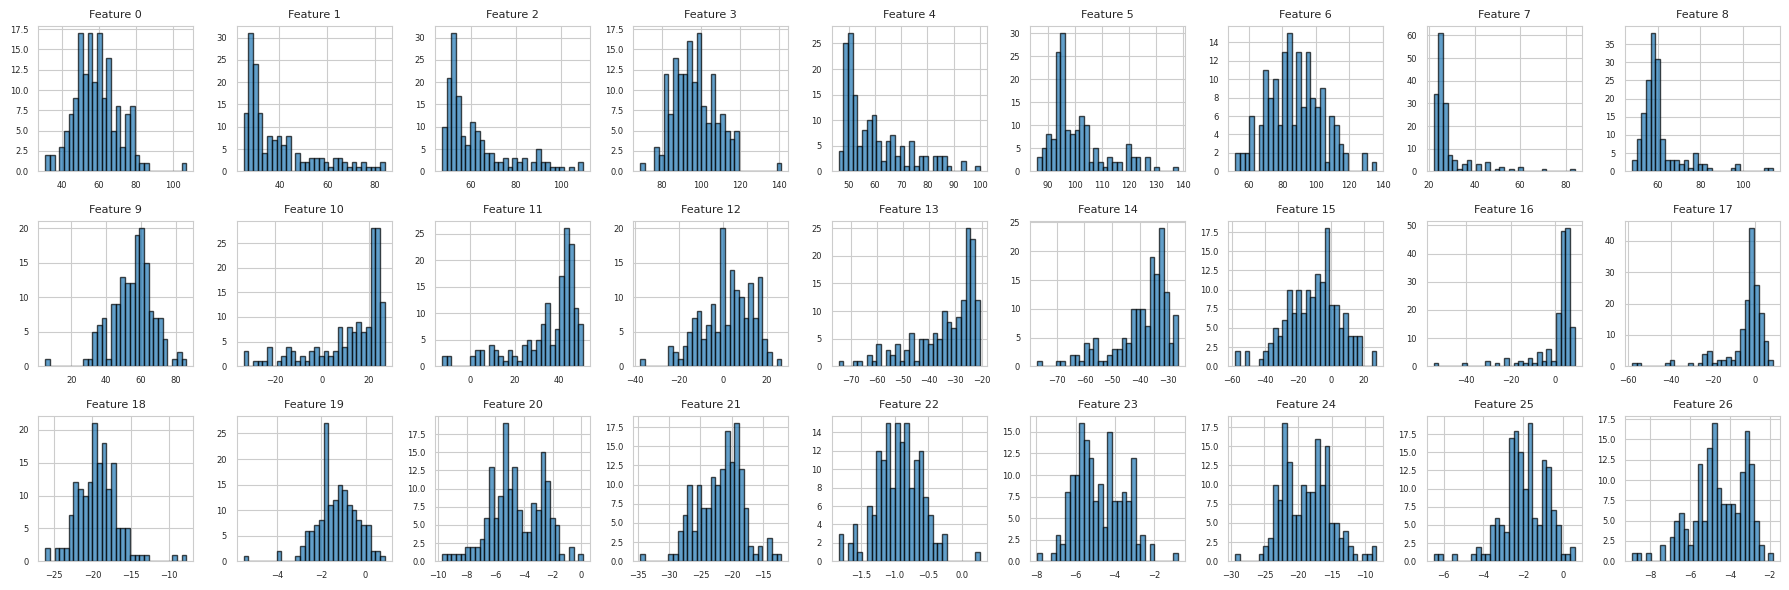

In [39]:
# Check data distributions for predictor variables

import matplotlib.pyplot as plt

for dataset in [X_train, X_val, X_test]:
    fig, axes = plt.subplots(3, 9, figsize=(18, 6))
    axes = axes.flatten()

    for idx in range(dataset.shape[1]):
        axes[idx].hist(dataset[:, idx], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Feature {idx}', fontsize=8)
        axes[idx].tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

#### Interpreting Data Distributions

There are to many variables to individually inspect, but at a glance a few variables can be seen following a normally distributed distribution, however, some are skewed, these will have to be transformed

## Pre-processing

The pre-processing is informed by the Exploratory Data Analysis


The only pre-processing requirement identified by the EDA was the need for more normally distributed feature variables. The selected approach is to use sklearn's [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)

### Power Transformer

In [40]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()

# Fit transformer on train set
X_train = pt.fit_transform(train.iloc[:,1:].to_numpy())

# Transform val and test sets
X_val = pt.transform(val.iloc[:,1:].to_numpy())
X_test = pt.transform(test.iloc[:,1:].to_numpy())

#### Confirming productivity of PowerTransformer

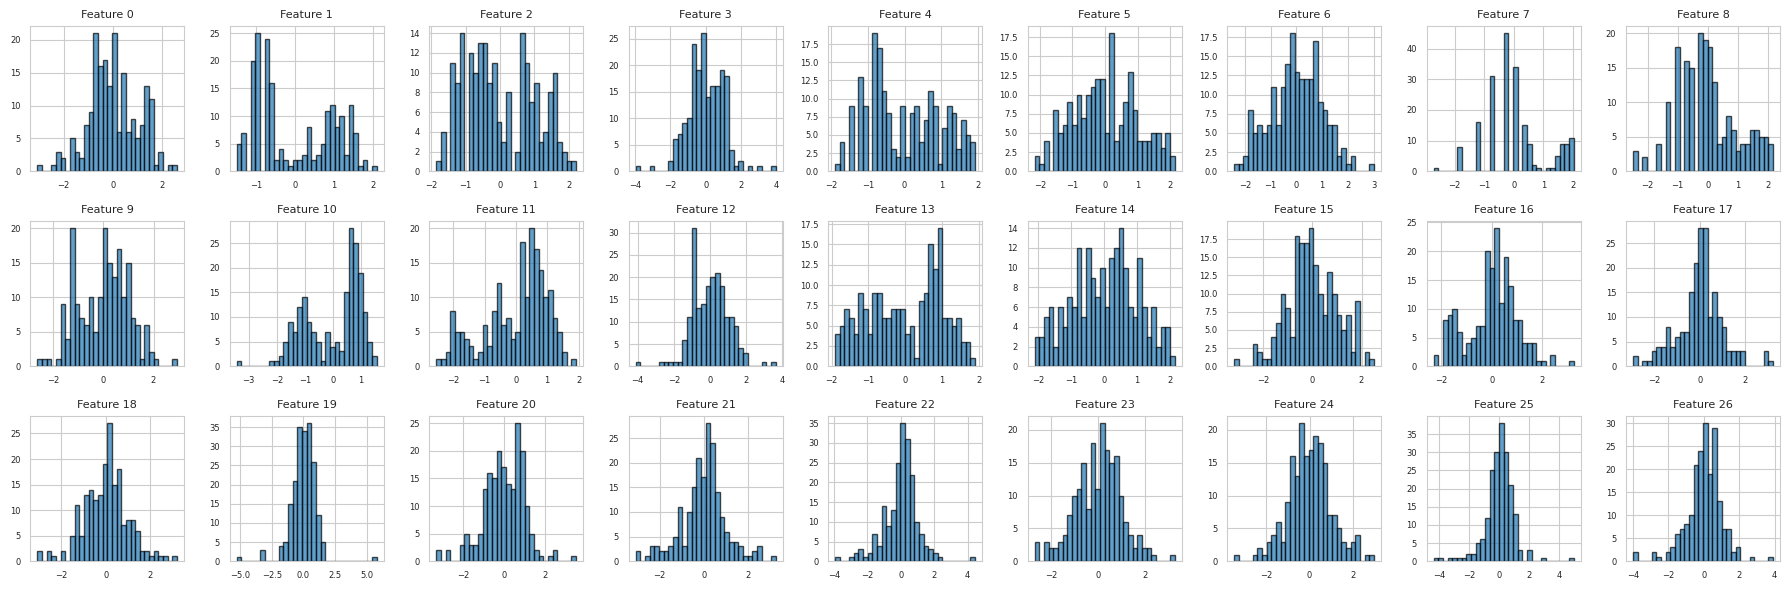

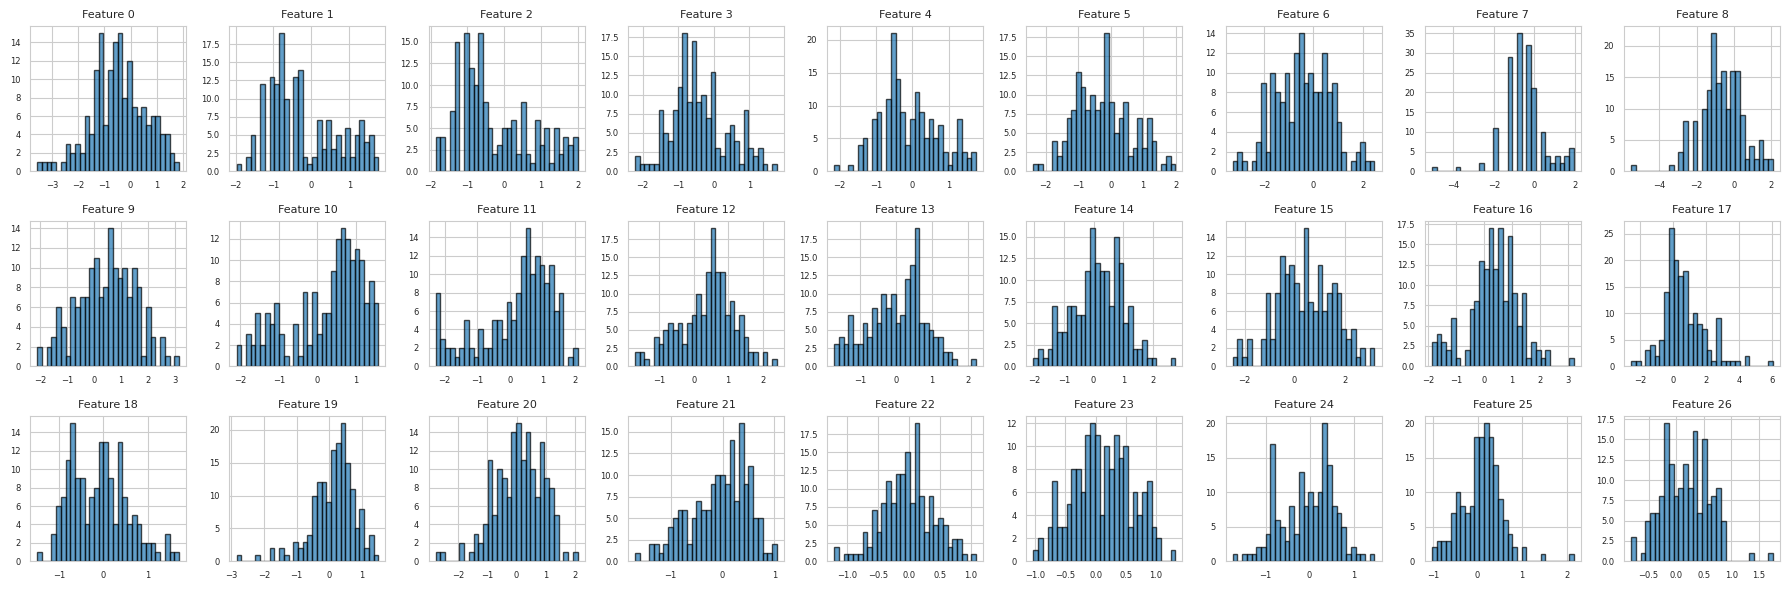

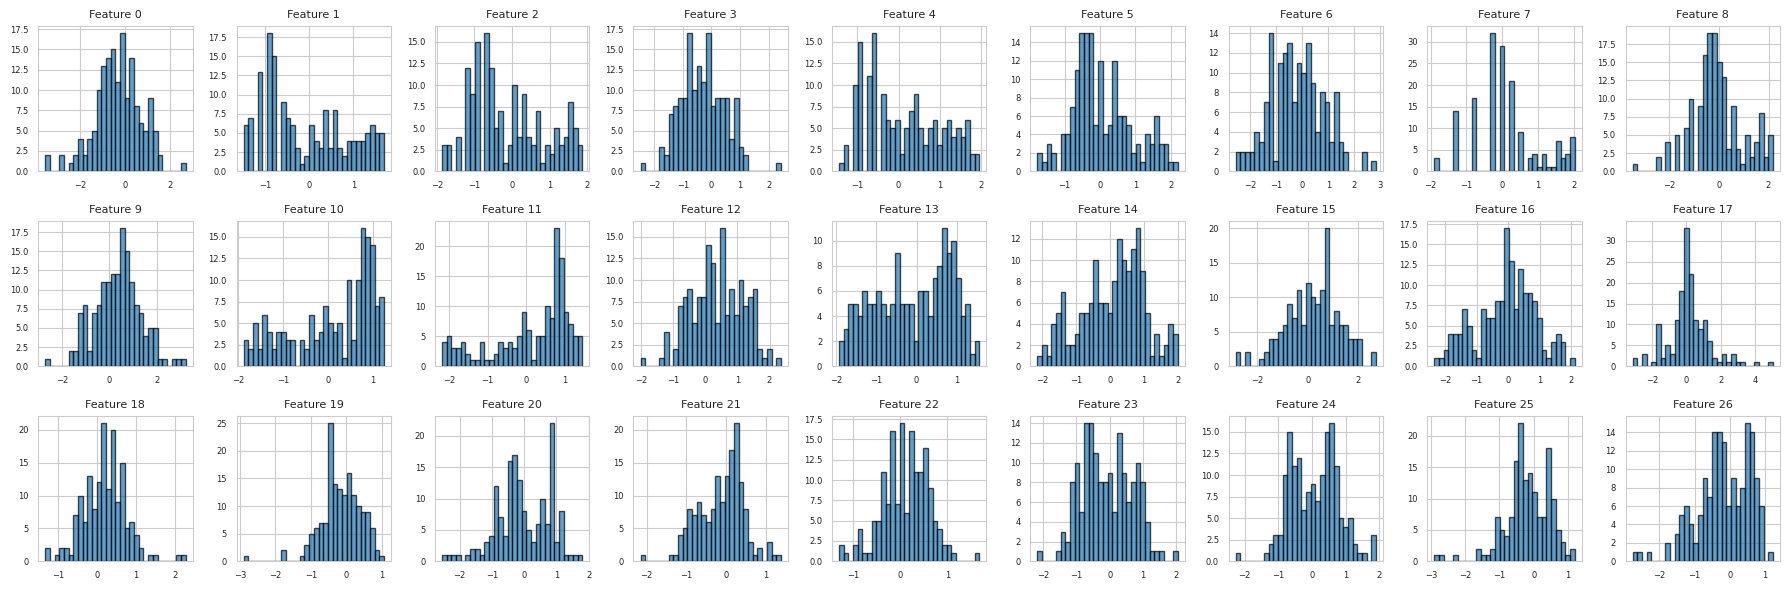

In [41]:
for dataset in [X_train, X_val, X_test]:
    fig, axes = plt.subplots(3, 9, figsize=(18, 6))
    axes = axes.flatten()

    for idx in range(dataset.shape[1]):
        axes[idx].hist(dataset[:, idx], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Feature {idx}', fontsize=8)
        axes[idx].tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

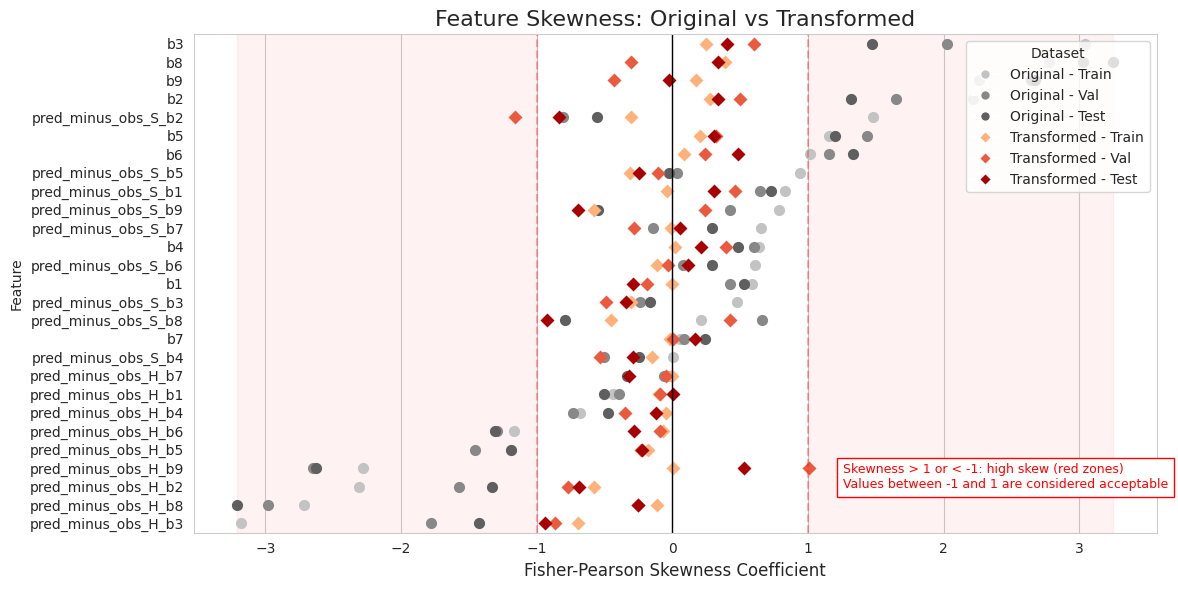

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

feature_cols = train.columns[1:]

train_orig = train[feature_cols]
val_orig = val[feature_cols]
test_orig = test[feature_cols]

train_transformed = pd.DataFrame(X_train, columns=feature_cols)
val_transformed = pd.DataFrame(X_val, columns=feature_cols)
test_transformed = pd.DataFrame(X_test, columns=feature_cols)

skew_data = pd.DataFrame({
    'Feature': feature_cols,
    'Train': train_orig.skew().values,
    'Val': val_orig.skew().values,
    'Test': test_orig.skew().values
})

skew_data_transformed = pd.DataFrame({
    'Feature': feature_cols,
    'Train': train_transformed.skew().values,
    'Val': val_transformed.skew().values,
    'Test': test_transformed.skew().values
})

sort_order = skew_data.sort_values(by='Train', ascending=False)['Feature']

df_original = skew_data.melt(id_vars='Feature', var_name='Dataset', value_name='Skewness')
df_transformed = skew_data_transformed.melt(id_vars='Feature', var_name='Dataset', value_name='Skewness')

all_skewness = pd.concat([df_original['Skewness'], df_transformed['Skewness']])

original_palette = {
    'Train': plt.cm.Greys(0.35),
    'Val':   plt.cm.Greys(0.55),
    'Test':  plt.cm.Greys(0.70),
}
transformed_palette = {
    'Train': plt.cm.OrRd(0.40),
    'Val':   plt.cm.OrRd(0.65),
    'Test':  plt.cm.OrRd(0.90),
}

fig, ax = plt.subplots(figsize=(12, 6))
sns.set_style('whitegrid')

sns.pointplot(
    data=df_original,
    x='Skewness',
    y='Feature',
    hue='Dataset',
    order=sort_order,
    linestyle='none',
    markers='o',
    markersize=6,
    palette=original_palette,
    ax=ax
)

sns.pointplot(
    data=df_transformed,
    x='Skewness',
    y='Feature',
    hue='Dataset',
    order=sort_order,
    linestyle='none',
    markers='D',
    markersize=5,
    palette=transformed_palette,
    ax=ax
)

ax.axvspan(1, all_skewness.max(), color='red', alpha=0.05)
ax.axvspan(all_skewness.min(), -1, color='red', alpha=0.05)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.3)
ax.axvline(x=-1, color='red', linestyle='--', alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=original_palette['Train'], markersize=7, label='Original - Train'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=original_palette['Val'],   markersize=7, label='Original - Val'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=original_palette['Test'],  markersize=7, label='Original - Test'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=transformed_palette['Train'], markersize=6, label='Transformed - Train'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=transformed_palette['Val'],   markersize=6, label='Transformed - Val'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=transformed_palette['Test'],  markersize=6, label='Transformed - Test'),
]
ax.legend(handles=legend_elements, title='Dataset', loc='upper right')

plt.title('Feature Skewness: Original vs Transformed', fontsize=16)
plt.xlabel('Fisher-Pearson Skewness Coefficient', fontsize=12)
ax.annotate(
    'Skewness > 1 or < -1: high skew (red zones)\nValues between -1 and 1 are considered acceptable',
    xy=(1, 0),
    xycoords=('data', 'axes fraction'),
    xytext=(25, 50),
    textcoords='offset points',
    fontsize=9,
    color='red',
    bbox=dict(facecolor='white', edgecolor='red'),
    va='top'
)
plt.tight_layout()
plt.show()


In [43]:
# Q2 asks you to use a grid search for each model. You are to evaluate the models on the validation set, and train on the train
# set. If you wish to use sklearn's GridSearchCV, you will need to setup a PredefinedSplit to pass into this. An appropraite
# PredefinedSplit object is created below.
X_train_and_val = np.vstack((X_train, X_val))
y_train_and_val = np.hstack((y_train, y_val))
mask = np.zeros(len(y_train_and_val))
mask[0:len(y_train)] = -1
train_val_split = PredefinedSplit(mask)

## Modelling

### Cleansed k-Nearest Neighbour (CKNN)

In [44]:
# Train your CKNN. You should consider the following parameters at least:
#  - K
#  - Distance Metric
#  - Weighting Scheme
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search, 
# though this is not required.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()
rand_search_knn = RandomizedSearchCV(knn, params, n_iter=20, cv=5)
rand_search_knn.fit(X_train, y_train)

print("KNN Best Parameters:", rand_search_knn.best_params_)
print("KNN Best Cross-Validation Score:", rand_search_knn.best_score_)

y_train_pred_knn = rand_search_knn.predict(X_train)
y_test_pred_knn = rand_search_knn.predict(X_test)
print("KNN Train Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("KNN Test Accuracy:", accuracy_score(y_test, y_test_pred_knn))
print(classification_report(y_test, y_test_pred_knn))

KNN Best Parameters: {'weights': 'uniform', 'n_neighbors': 1}
KNN Best Cross-Validation Score: 0.9747435897435898
KNN Train Accuracy: 1.0
KNN Test Accuracy: 0.8385093167701864
              precision    recall  f1-score   support

          d        0.83      0.91      0.86        53
          h        0.59      0.87      0.70        15
          o        0.96      0.74      0.84        31
          s        0.89      0.82      0.86        62

    accuracy                           0.84       161
   macro avg       0.82      0.83      0.82       161
weighted avg       0.86      0.84      0.84       161



### Support Vector Machine (SVM)

In [45]:
# Train your SVM. You should consider the following parameters at least:
#  - C
#  - Kernel Type
#  - Kernel Parameters
#  - Ensemble scheme (i.e. "one vs one" or "one vs all")
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search, 
# though this is not required.

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
    {'C': [0.1, 1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']},
    {'C': [0.1, 1, 10, 100, 1000], 'degree': [3, 4, 5, 6], 'kernel': ['poly']},
]

svm = SVC()
grid_search_svm = GridSearchCV(svm, param_grid, cv=5)
grid_search_svm.fit(X_train, y_train)

print("SVM Best Parameters:", grid_search_svm.best_params_)
print("SVM Best Cross-Validation Score:", grid_search_svm.best_score_)

y_train_pred_svm = grid_search_svm.predict(X_train)
y_test_pred_svm = grid_search_svm.predict(X_test)
print("SVM Train Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("SVM Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print(classification_report(y_test, y_test_pred_svm))

SVM Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVM Best Cross-Validation Score: 0.9798717948717949
SVM Train Accuracy: 1.0
SVM Test Accuracy: 0.84472049689441
              precision    recall  f1-score   support

          d        0.87      0.87      0.87        53
          h        0.57      0.87      0.68        15
          o        0.86      0.81      0.83        31
          s        0.93      0.84      0.88        62

    accuracy                           0.84       161
   macro avg       0.81      0.84      0.82       161
weighted avg       0.86      0.84      0.85       161



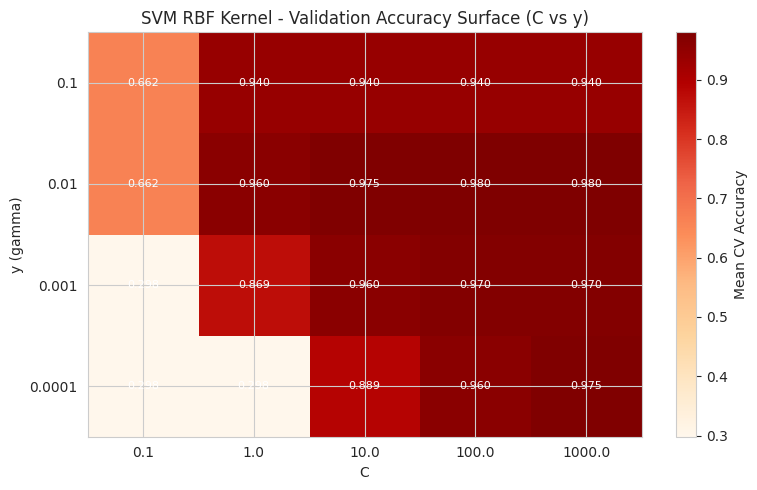

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Extract RBF kernel results from GridSearchCV
results = grid_search_svm.cv_results_
mask = np.array(results['param_kernel']) == 'rbf'

C_vals = np.array(results['param_C'][mask], dtype=float)
gamma_vals = np.array(results['param_gamma'][mask], dtype=float)
scores = results['mean_test_score'][mask]

C_unique = np.sort(np.unique(C_vals))
gamma_unique = np.sort(np.unique(gamma_vals))

# Build accuracy surface matrix (rows=gamma, cols=C)
acc_surface = np.zeros((len(gamma_unique), len(C_unique)))
for i, g in enumerate(gamma_unique):
    for j, c in enumerate(C_unique):
        idx = np.where((gamma_vals == g) & (C_vals == c))[0]
        acc_surface[i, j] = scores[idx[0]]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(acc_surface, aspect='auto', cmap='OrRd', origin='lower')

ax.set_xticks(range(len(C_unique)))
ax.set_xticklabels([str(c) for c in C_unique])
ax.set_yticks(range(len(gamma_unique)))
ax.set_yticklabels([str(g) for g in gamma_unique])

ax.set_xlabel('C')
ax.set_ylabel('y (gamma)')
ax.set_title('SVM RBF Kernel - Validation Accuracy Surface (C vs y)')

plt.colorbar(im, ax=ax, label='Mean CV Accuracy')

# Annotate each cell with its accuracy
for i in range(len(gamma_unique)):
    for j in range(len(C_unique)):
        ax.text(j, i, f'{acc_surface[i, j]:.3f}',
                ha='center', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('Fig2.2.png', dpi=150)
plt.show()


### Random Forest (RF)

In [47]:
# Train your RF. You should consider the following parameters at least:
#  - Tree depth
#  - Number of estimators
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search, 
# though this is not required.

from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid = {
    'max_depth': [2, 4, None],
    'min_samples_split': [5, 10],
    'n_estimators': [25, 50, 100]
}

rf = RandomForestClassifier(random_state=42)
halving_search_rf = HalvingGridSearchCV(rf, param_grid, cv=5, random_state=42)
halving_search_rf.fit(X_train, y_train)

print("Random Forest Best Parameters:", halving_search_rf.best_params_)
print("Random Forest Best Cross-Validation Score:", halving_search_rf.best_score_)

y_train_pred_rf = halving_search_rf.predict(X_train)
y_test_pred_rf = halving_search_rf.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf))

Random Forest Best Parameters: {'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 100}
Random Forest Best Cross-Validation Score: 0.9829710144927537
Random Forest Test Accuracy: 0.9797979797979798
Random Forest Test Accuracy: 0.8074534161490683
              precision    recall  f1-score   support

          d        0.81      0.74      0.77        53
          h        0.72      0.87      0.79        15
          o        0.92      0.77      0.84        31
          s        0.78      0.87      0.82        62

    accuracy                           0.81       161
   macro avg       0.81      0.81      0.81       161
weighted avg       0.81      0.81      0.81       161



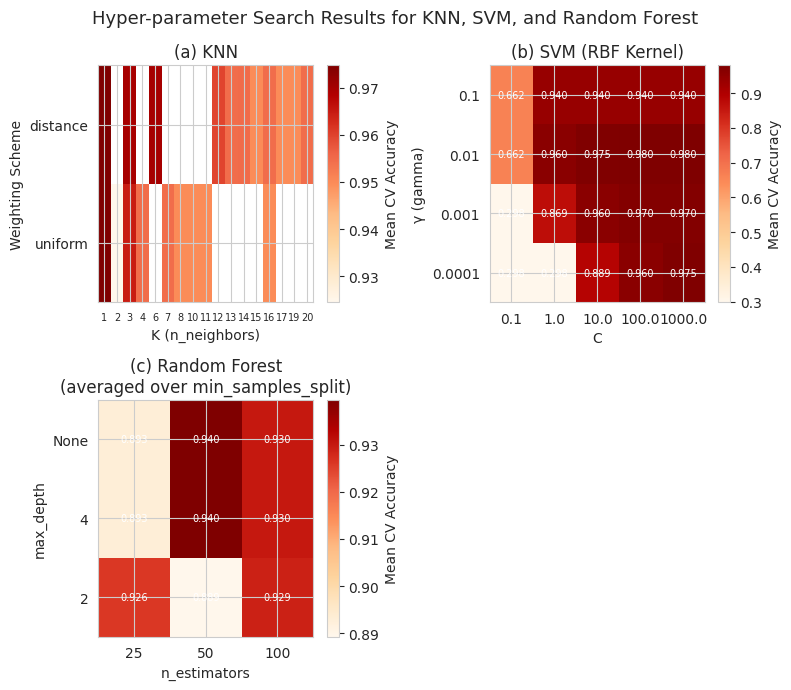

In [48]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(8, 7))
fig.suptitle('Hyper-parameter Search Results for KNN, SVM, and Random Forest', fontsize=13)

# ── (a) KNN: K vs Weighting Scheme ──────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)

knn_results = rand_search_knn.cv_results_
k_vals      = np.array(knn_results['param_n_neighbors'], dtype=float)
weight_vals = np.array(knn_results['param_weights'])
scores_knn  = knn_results['mean_test_score']

k_unique = np.sort(np.unique(k_vals).astype(int))
w_unique = ['uniform', 'distance']

knn_surface = np.full((len(w_unique), len(k_unique)), np.nan)
for score, k, w in zip(scores_knn, k_vals, weight_vals):
    i = w_unique.index(w)
    j = np.where(k_unique == int(k))[0][0]
    knn_surface[i, j] = score

im1 = ax1.imshow(knn_surface, aspect='auto', cmap='OrRd', origin='lower',
                 vmin=np.nanmin(knn_surface), vmax=np.nanmax(knn_surface))
ax1.set_xticks(range(len(k_unique)))
ax1.set_xticklabels(k_unique, fontsize=7)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(w_unique)
ax1.set_xlabel('K (n_neighbors)')
ax1.set_ylabel('Weighting Scheme')
ax1.set_title('(a) KNN')
plt.colorbar(im1, ax=ax1, label='Mean CV Accuracy')

# ── (b) SVM RBF: C vs γ ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)

svm_results = grid_search_svm.cv_results_
mask        = np.array(svm_results['param_kernel']) == 'rbf'
C_vals      = np.array(svm_results['param_C'][mask], dtype=float)
gamma_vals  = np.array(svm_results['param_gamma'][mask], dtype=float)
scores_svm  = svm_results['mean_test_score'][mask]

C_unique     = np.sort(np.unique(C_vals))
gamma_unique = np.sort(np.unique(gamma_vals))

svm_surface = np.zeros((len(gamma_unique), len(C_unique)))
for score, c, g in zip(scores_svm, C_vals, gamma_vals):
    i = np.where(gamma_unique == g)[0][0]
    j = np.where(C_unique == c)[0][0]
    svm_surface[i, j] = score

im2 = ax2.imshow(svm_surface, aspect='auto', cmap='OrRd', origin='lower')
ax2.set_xticks(range(len(C_unique)))
ax2.set_xticklabels([str(c) for c in C_unique])
ax2.set_yticks(range(len(gamma_unique)))
ax2.set_yticklabels([str(g) for g in gamma_unique])
ax2.set_xlabel('C')
ax2.set_ylabel('γ (gamma)')
ax2.set_title('(b) SVM (RBF Kernel)')
plt.colorbar(im2, ax=ax2, label='Mean CV Accuracy')
for i in range(len(gamma_unique)):
    for j in range(len(C_unique)):
        ax2.text(j, i, f'{svm_surface[i, j]:.3f}',
                 ha='center', va='center', color='white', fontsize=7)

# ── (c) RF: n_estimators vs max_depth (per min_samples_split) ───────────────
ax3 = fig.add_subplot(2, 2, 3)

rf_results        = halving_search_rf.cv_results_
n_est_vals        = np.array(rf_results['param_n_estimators'], dtype=float)
depth_vals        = np.array(rf_results['param_max_depth'])       # may contain None
split_vals        = np.array(rf_results['param_min_samples_split'], dtype=float)
scores_rf         = rf_results['mean_test_score']

# Average over min_samples_split to get a 2D surface
n_unique   = np.sort(np.unique(n_est_vals).astype(int))
# Replace None with 'None' string for labelling
depth_labels = ['None' if d is None else str(d) for d in [2, 4, None]]
depth_keys   = [2, 4, None]

rf_surface = np.full((len(depth_keys), len(n_unique)), np.nan)
counts     = np.zeros_like(rf_surface)
for score, n, d, s in zip(scores_rf, n_est_vals, depth_vals, split_vals):
    try:
        i = depth_keys.index(d)
    except ValueError:
        continue
    j = np.where(n_unique == int(n))[0]
    if len(j) == 0:
        continue
    j = j[0]
    if np.isnan(rf_surface[i, j]):
        rf_surface[i, j] = score
        counts[i, j] = 1
    else:
        rf_surface[i, j] += score
        counts[i, j] += 1

with np.errstate(invalid='ignore'):
    rf_surface = rf_surface / counts

im3 = ax3.imshow(rf_surface, aspect='auto', cmap='OrRd', origin='lower',
                 vmin=np.nanmin(rf_surface), vmax=np.nanmax(rf_surface))
ax3.set_xticks(range(len(n_unique)))
ax3.set_xticklabels(n_unique)
ax3.set_yticks(range(len(depth_keys)))
ax3.set_yticklabels(depth_labels)
ax3.set_xlabel('n_estimators')
ax3.set_ylabel('max_depth')
ax3.set_title('(c) Random Forest\n(averaged over min_samples_split)')
plt.colorbar(im3, ax=ax3, label='Mean CV Accuracy')
for i in range(len(depth_keys)):
    for j in range(len(n_unique)):
        if not np.isnan(rf_surface[i, j]):
            ax3.text(j, i, f'{rf_surface[i, j]:.3f}',
                     ha='center', va='center', color='white', fontsize=7)

# ── (d) Empty slot — hidden ──────────────────────────────────────────────────
fig.add_subplot(2, 2, 4).set_visible(False)

plt.tight_layout()
plt.savefig('Fig2.2.png', dpi=150)
plt.show()


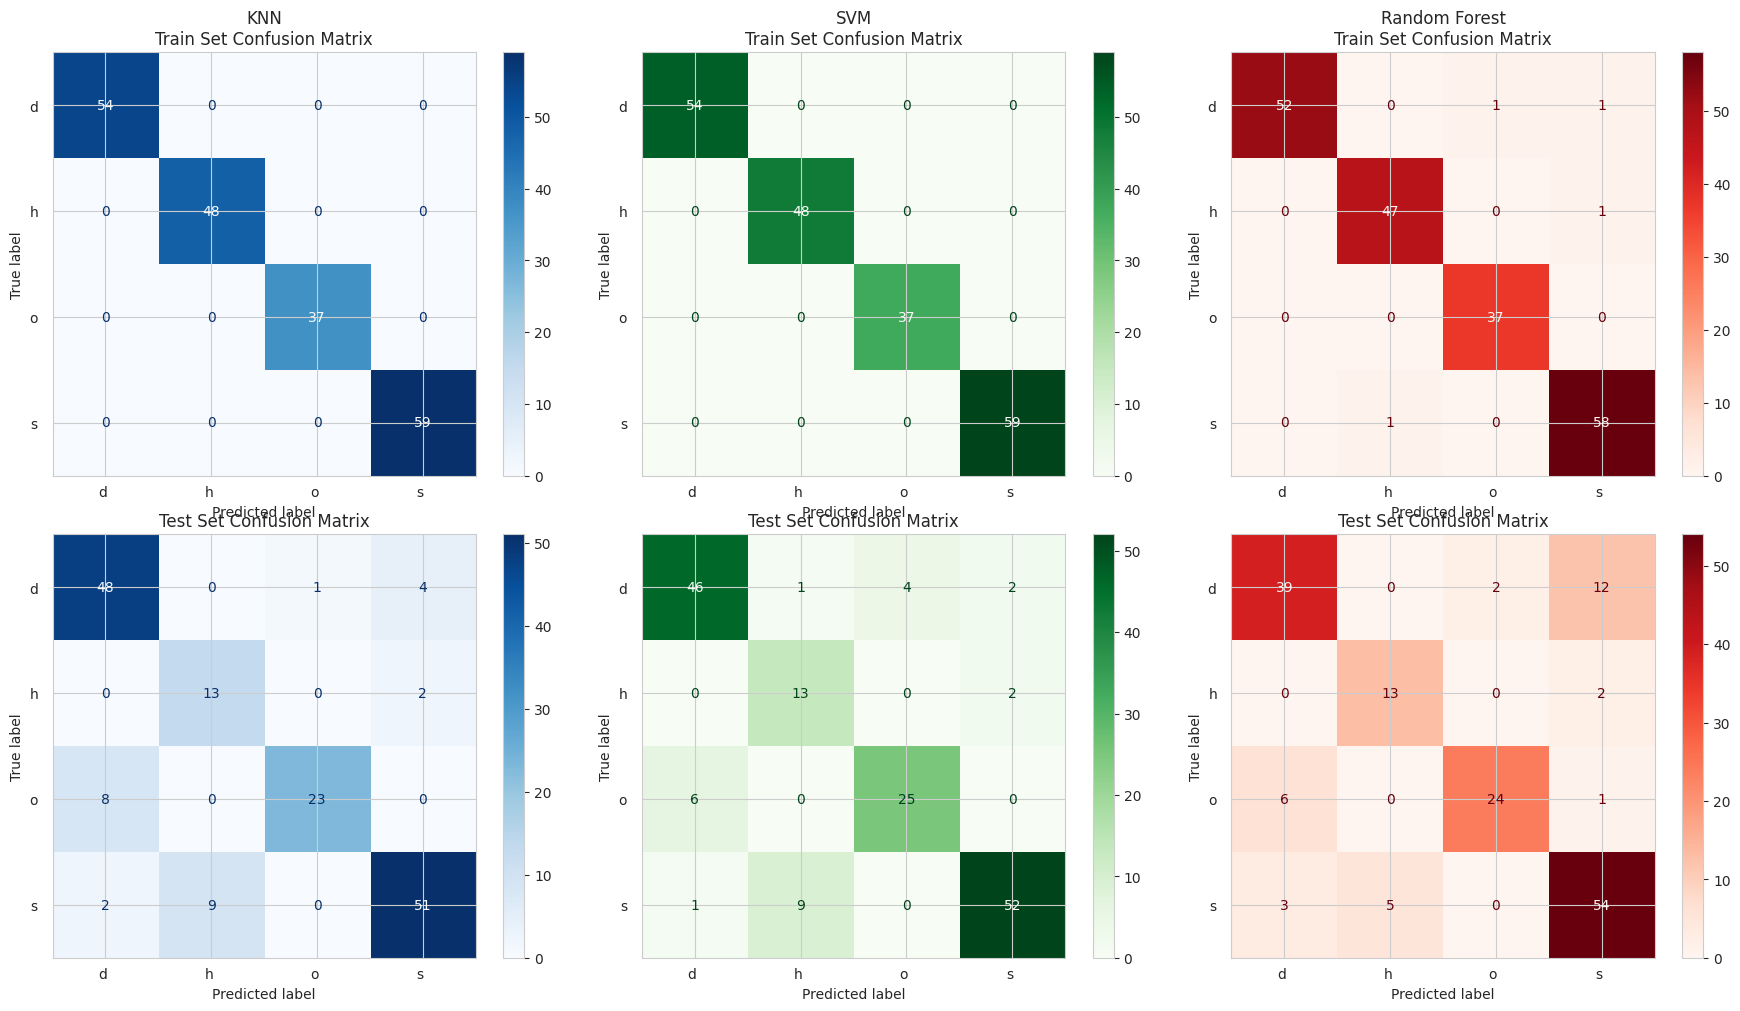

In [49]:
# Evaluate the three methods. This should consider appropriate performance measures for the classifiers, such as F1, and 
# visualisations of performance (i.e. confusion matrices) that demonstrate any difference in perfomance between the models.

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_knn, ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('KNN\nTrain Set Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn, ax=axes[1, 0], cmap='Blues')
axes[1, 0].set_title('Test Set Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_svm, ax=axes[0, 1], cmap='Greens')
axes[0, 1].set_title('SVM\nTrain Set Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svm, ax=axes[1, 1], cmap='Greens')
axes[1, 1].set_title('Test Set Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_rf, ax=axes[0, 2], cmap='Reds')
axes[0, 2].set_title('Random Forest\nTrain Set Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf, ax=axes[1, 2], cmap='Reds')
axes[1, 2].set_title('Test Set Confusion Matrix')

plt.tight_layout()
plt.show()

In [50]:
comparison = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Random Forest'],
    'Training Accuracy': [
        accuracy_score(y_train, y_train_pred_knn),
        accuracy_score(y_train, y_train_pred_svm),
        accuracy_score(y_train, y_train_pred_rf)
    ],
    'Validation Accuracy': [
        accuracy_score(y_val, y_val_pred_knn),
        accuracy_score(y_val, y_val_pred_svm),
        accuracy_score(y_val, y_val_pred_rf)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred_knn),
        accuracy_score(y_test, y_test_pred_svm),
        accuracy_score(y_test, y_test_pred_rf)
    ]
})
display(comparison)

NameError: name 'y_val_pred_knn' is not defined

In [ ]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the hyper-parameters for each of your models, and how these may be influenced by any data 
#   characteristics, and any effect you may see from the selected hyper-parameters (ie. if you have found a small value for a 
#   hyper parameter, what effect will this have on the model compared to a large value?) 
# - an evaluation and comparison of three models, which should highlight any differences observed between the models
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions.
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT